# Assignment 4 – CNN for Image Classification

| Field | Details |
|---|---|
| **Assignment** | Assignment 4 – Unit 3: CNNs |
| Student Name | Sachin Shrestha |
| Student ID | 032338-22 |
| Date | 26 April 2026 |
| Dataset | CIFAR-10 (60 000 colour images, 10 classes) |

---


## 1. Objective

- Implement a Convolutional Neural Network (CNN) in PyTorch and train it on CIFAR-10.
- Build a baseline Multi-Layer Perceptron (MLP) on the same dataset for direct comparison.
- Experiment with architectural hyper-parameters: filter sizes, number of filters, and pooling strategies.
- Evaluate both models using accuracy, loss curves, and confusion matrices.
- Visualise intermediate feature maps to develop intuition for spatial feature learning.


## 2. Theoretical Background

### 2.1 Convolutional Layer
A 2-D convolution applies a learnable filter **W** of size $k \times k$ across the spatial dimensions of an input feature map $X$:

$$
(X * W)[i,j] = \sum_{m=0}^{k-1}\sum_{n=0}^{k-1} X[i+m,\; j+n]\cdot W[m,n] + b
$$

The output size after convolution (no padding) is:

$$
H_{out} = \left\lfloor \frac{H_{in} - k}{s} \right\rfloor + 1
$$

where $s$ is the stride.

### 2.2 Activation – ReLU
$$
\text{ReLU}(x) = \max(0,\, x)
$$
Introduces non-linearity while avoiding the vanishing-gradient problem of sigmoid/tanh.

### 2.3 Pooling
**Max-Pooling** selects the maximum activation in a local $p \times p$ window, providing spatial down-sampling and translation invariance:

$$
y_{i,j} = \max_{(m,n)\in\mathcal{R}_{i,j}} x_{m,n}
$$

**Average-Pooling** computes the mean instead, producing smoother responses.

### 2.4 Batch Normalisation
Normalises activations over a mini-batch, stabilising training and acting as a regulariser:

$$
\hat{x} = \frac{x - \mu_\mathcal{B}}{\sqrt{\sigma_\mathcal{B}^2 + \epsilon}}, \qquad y = \gamma\hat{x} + \beta
$$

### 2.5 Fully-Connected Head & Softmax
After flattening the feature maps, dense layers map representations to class logits. Softmax converts logits to probabilities:

$$
P(y=c\mid x) = \frac{e^{z_c}}{\sum_{j=1}^{C} e^{z_j}}
$$

### 2.6 Why CNNs Outperform MLPs on Images

| Property | MLP | CNN |
|---|---|---|
| Parameter sharing | ✗ – each weight is unique | ✓ – filter weights shared over the whole image |
| Local connectivity | ✗ – every pixel connected to every neuron | ✓ – each neuron sees only a local receptive field |
| Translation invariance | ✗ | ✓ – pooling provides approximate invariance |
| Parameter count (CIFAR-10 input 3072) | very large | compact |

---


## 3. Dataset & Preprocessing

**CIFAR-10** – 60,000 RGB 32×32 images across 10 classes ([source](https://www.cs.toronto.edu/~kriz/cifar.html)).

| Property | Value |
|---|---|
| Total samples | 60 000 colour images |
| Train / Val / Test | 22,500 / 5,000 / 10,000 |
| Image size | 32 × 32 × 3 |
| Classes | plane, car, bird, cat, deer, dog, frog, horse, ship, truck |

Per-channel normalisation; training augmentation: random crop (padding=4) + horizontal flip; no augmentation on val/test.


In [1]:
import random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")

#  Global hyper-parameters (baseline)
BATCH_SIZE   = 256
EPOCHS       = 15        
LR           = 1e-3
WEIGHT_DECAY = 1e-4

CLASSES = ('plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck')


PyTorch  : 2.9.1+cpu
Device   : cpu


## 3.1 Dataset Preprocessing Pipeline

Train samples : 22500
Val   samples : 5000
Test  samples : 10000
Batches/epoch : 88


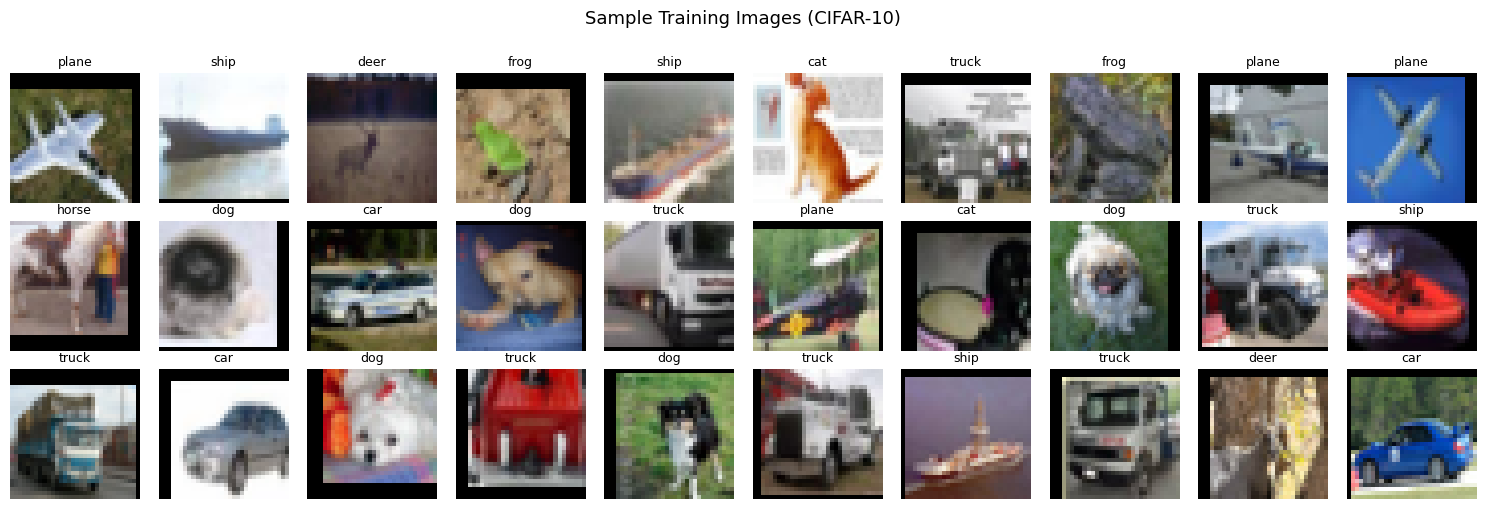

Figure saved → sample_images.png


In [ ]:
# Normalisation statistics (CIFAR-10 channel means & stds)
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # random crop augmentation
    transforms.RandomHorizontalFlip(),            
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Download / load
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=test_transform)

# Train / validation split (90 / 10)
val_size   = int(0.10 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))

# Use 50%(~22,500) dataset for training (reduces time)
half = int(0.5 * len(train_set))
train_set, _ = random_split(train_set, [half, len(train_set) - half],
                            generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train samples : {len(train_set)}")
print(f"Val   samples : {len(val_set)}")
print(f"Test  samples : {len(test_set)}")
print(f"Batches/epoch : {len(train_loader)}")


def imshow(img, ax, title=''):
    #Denormalise and display a single tensor image on *ax*.
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    img  = img * std + mean          # undo normalisation
    img  = img.permute(1,2,0).numpy()
    img  = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    imshow(imgs[i], ax, CLASSES[labels[i]])
plt.suptitle('Sample Training Images (CIFAR-10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved → sample_images.png")


## 4. Model Architectures

### MLP Baseline
Fully-connected: 3072 → 1024 → 512 → 256 → 10, with BatchNorm + ReLU + Dropout(0.4) between each layer.

### CNN (Baseline)
Three convolutional blocks (Conv→BN→ReLU×2 → Pool → Dropout2d), followed by a FC head:
- **Block 1:** 32 filters, 3×3, MaxPool → 16×16
- **Block 2:** 64 filters, 3×3, MaxPool → 8×8
- **Block 3:** 128 filters, 3×3, AvgPool → 4×4
- **Head:** Flatten → FC(2048→256) → Dropout(0.5) → FC(256→10)
Kaiming weight initialisation throughout.


In [3]:
class MLP(nn.Module):
    """
    Fully-connected MLP baseline.
    Input: 32x32x3 = 3072 flattened pixels
    """
    def __init__(self, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),     nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),      nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP().to(DEVICE)
total_params_mlp = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP total trainable parameters: {total_params_mlp:,}")
print(mlp)


class CNN(nn.Module):   
    #Baseline CNN for CIFAR-10.
    def __init__(self, dropout=0.25):
        super().__init__()

        # Convolutional blocks
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                   # 32→16
            nn.Dropout2d(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                   # 16→8
            nn.Dropout2d(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AvgPool2d(2),                                                    # 8→4
            nn.Dropout2d(dropout)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),              # 128 * 4 * 4 = 2048
            nn.Linear(128*4*4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

        # Weight initialisation (Kaiming)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

cnn = CNN().to(DEVICE)
total_params_cnn = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"CNN total trainable parameters: {total_params_cnn:,}")
print(cnn)


MLP total trainable parameters: 3,809,034
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=1024, bias=True)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=1024, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.4, inplace=False)
    (13): Linear(in_features=256, out_features=10, bias=True)
  )
)
CNN total trainable parameters: 815,018
CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, a

## 5. Training Utilities

Training loop uses Cross-Entropy (label smoothing=0.05), Adam + weight decay, and CosineAnnealingLR. Best validation weights are restored at the end.


In [4]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY, name='Model'):
    """
    Full training loop with:
      - Cross-entropy loss
      - Adam optimiser + weight decay
      - CosineAnnealingLR scheduler
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc  = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc  = eval_epoch(model, val_loader,   criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f"[{name}] Ep {epoch:3d}/{epochs} | "
                  f"Train Loss {tr_loss:.4f} Acc {tr_acc*100:.2f}% | "
                  f"Val Loss {vl_loss:.4f} Acc {vl_acc*100:.2f}% | "
                  f"Time {elapsed:.0f}s")

    # restore best weights
    model.load_state_dict(best_state)
    print(f"\n[{name}] Best val acc: {best_val_acc*100:.2f}%  (weights restored)")
    return history


## 6. Experiments

Four configurations are compared:
1. **MLP baseline** – fully-connected reference.
2. **CNN (MaxPool)** – baseline CNN with max-pooling.
3. **CNN (AvgPool)** – all three blocks use average-pooling.
4. **CNN (5×5 filters)** – Block 1 uses 5×5 kernels instead of 3×3.


In [5]:
# Experiment 1: MLP Baseline
mlp = MLP().to(DEVICE)
history_mlp = train_model(mlp, train_loader, val_loader, epochs=EPOCHS, name='MLP')

# Experiment 2: CNN (MaxPool)
cnn = CNN().to(DEVICE)
history_cnn = train_model(cnn, train_loader, val_loader, epochs=EPOCHS, name='CNN')


[MLP] Ep   1/15 | Train Loss 2.0336 Acc 26.70% | Val Loss 1.8707 Acc 33.08% | Time 13s
[MLP] Ep   5/15 | Train Loss 1.7495 Acc 39.28% | Val Loss 1.7049 Acc 40.96% | Time 65s
[MLP] Ep  10/15 | Train Loss 1.6448 Acc 43.83% | Val Loss 1.5814 Acc 46.02% | Time 130s
[MLP] Ep  15/15 | Train Loss 1.6070 Acc 45.27% | Val Loss 1.5445 Acc 47.82% | Time 196s

[MLP] Best val acc: 47.82%  (weights restored)
[CNN] Ep   1/15 | Train Loss 2.1225 Acc 23.27% | Val Loss 1.8511 Acc 35.88% | Time 47s
[CNN] Ep   5/15 | Train Loss 1.6978 Acc 41.26% | Val Loss 1.5152 Acc 48.46% | Time 237s
[CNN] Ep  10/15 | Train Loss 1.5009 Acc 50.53% | Val Loss 1.3413 Acc 56.48% | Time 475s
[CNN] Ep  15/15 | Train Loss 1.4262 Acc 53.54% | Val Loss 1.2669 Acc 59.48% | Time 713s

[CNN] Best val acc: 59.50%  (weights restored)


In [6]:
# Experiment 3: CNN (AvgPool)
class CNN_AvgPool(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.AvgPool2d(2), nn.Dropout2d(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.AvgPool2d(2), nn.Dropout2d(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AvgPool2d(2), nn.Dropout2d(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

print("=" * 60)
print("Training CNN with Average-Pooling")
print("=" * 60)
cnn_avg = CNN_AvgPool().to(DEVICE)
history_cnn_avg = train_model(cnn_avg, train_loader, val_loader, epochs=EPOCHS, name='CNN-AvgPool')

# Experiment 4: CNN (5*5 Filters)
class CNN_LargeFilter(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=5, padding=2), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=5, padding=2), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AvgPool2d(2), nn.Dropout2d(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

print("=" * 60)
print("Training CNN with 5x5 filters in Block 1")
print("=" * 60)
cnn_lf = CNN_LargeFilter().to(DEVICE)
history_cnn_lf = train_model(cnn_lf, train_loader, val_loader, epochs=EPOCHS, name='CNN-5x5')


Training CNN with Average-Pooling
[CNN-AvgPool] Ep   1/15 | Train Loss 1.9484 Acc 29.01% | Val Loss 1.7323 Acc 39.02% | Time 48s
[CNN-AvgPool] Ep   5/15 | Train Loss 1.5353 Acc 48.66% | Val Loss 1.3808 Acc 54.94% | Time 236s
[CNN-AvgPool] Ep  10/15 | Train Loss 1.2974 Acc 59.70% | Val Loss 1.1673 Acc 63.86% | Time 471s
[CNN-AvgPool] Ep  15/15 | Train Loss 1.2109 Acc 63.40% | Val Loss 1.0944 Acc 67.14% | Time 705s

[CNN-AvgPool] Best val acc: 67.28%  (weights restored)
Training CNN with 5x5 filters in Block 1
[CNN-5x5] Ep   1/15 | Train Loss 1.9792 Acc 27.89% | Val Loss 1.7656 Acc 36.62% | Time 54s
[CNN-5x5] Ep   5/15 | Train Loss 1.5553 Acc 46.95% | Val Loss 1.4298 Acc 52.62% | Time 270s
[CNN-5x5] Ep  10/15 | Train Loss 1.3188 Acc 58.48% | Val Loss 1.1760 Acc 63.64% | Time 539s
[CNN-5x5] Ep  15/15 | Train Loss 1.2291 Acc 62.36% | Val Loss 1.1119 Acc 66.28% | Time 804s

[CNN-5x5] Best val acc: 66.28%  (weights restored)


## 7. Results


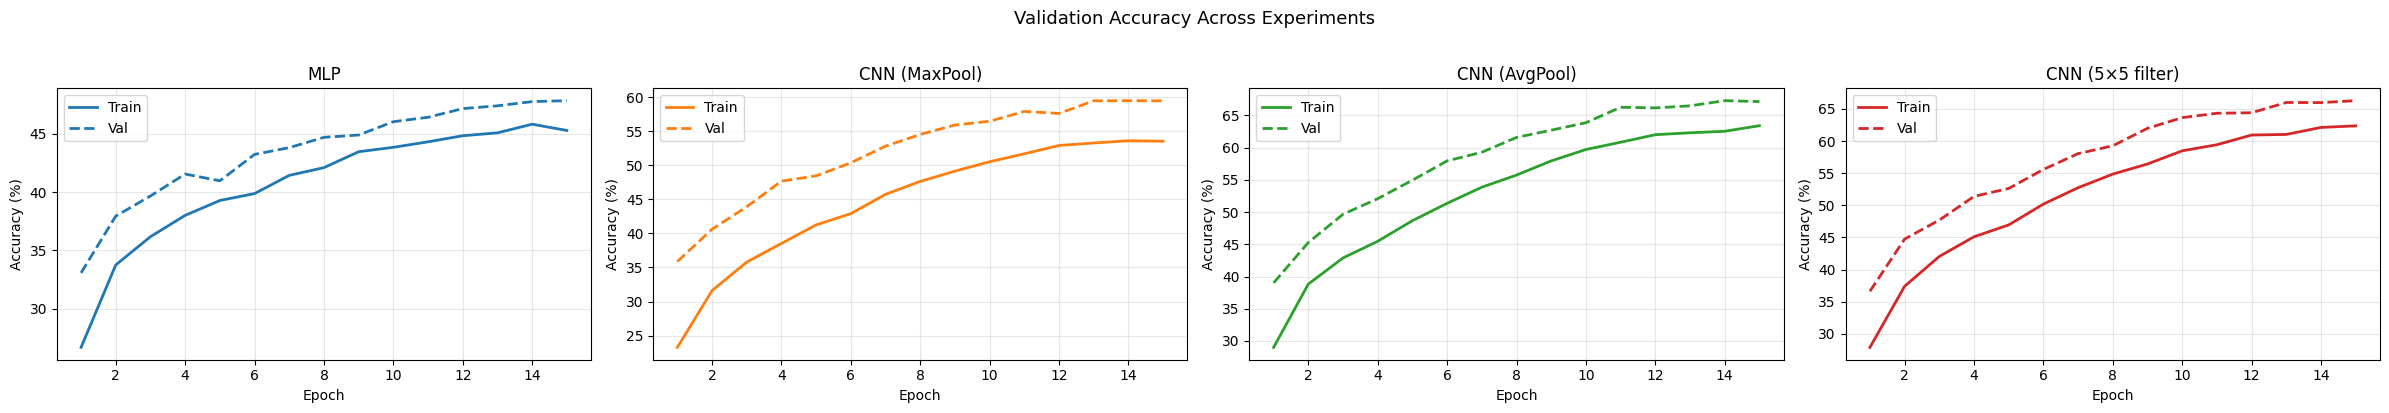

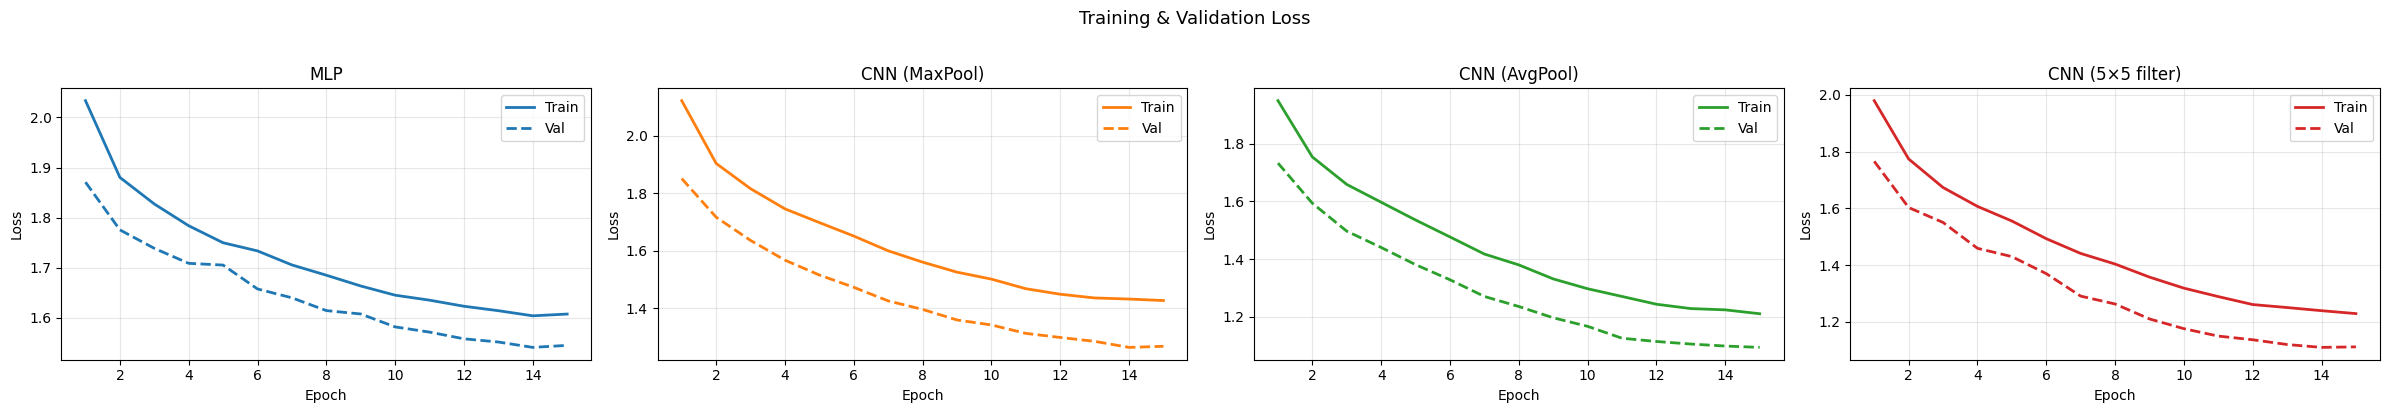


Model                     | Test Loss  | Test Acc
MLP                       | Test Loss: 1.3911 | Test Acc: 50.22%
CNN (MaxPool)             | Test Loss: 1.0574 | Test Acc: 62.45%
CNN (AvgPool)             | Test Loss: 0.8875 | Test Acc: 68.60%
CNN (5×5 filter)          | Test Loss: 0.8880 | Test Acc: 68.65%


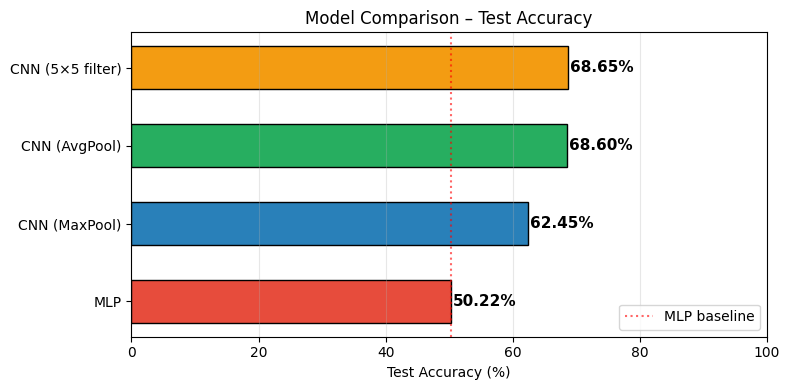

In [8]:
def plot_history(histories, names, metric='acc', title='', save_path=None):
    #Plot train/val metric for multiple models side-by-side.
    fig, axes = plt.subplots(1, len(histories), figsize=(6*len(histories), 4), sharey=False)
    if len(histories) == 1:
        axes = [axes]
    cmap = plt.colormaps['tab10']
    for ax, hist, name, color in zip(axes, histories, names, cmap.colors):
        epochs_range = range(1, len(hist[f'train_{metric}'])+1)
        tr = [v*100 if metric=='acc' else v for v in hist[f'train_{metric}']]
        vl = [v*100 if metric=='acc' else v for v in hist[f'val_{metric}']]
        ax.plot(epochs_range, tr, label='Train', color=color, lw=2)
        ax.plot(epochs_range, vl, label='Val',   color=color, lw=2, linestyle='--')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy (%)' if metric=='acc' else 'Loss')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

all_histories = [history_mlp, history_cnn, history_cnn_avg, history_cnn_lf]
all_names     = ['MLP', 'CNN (MaxPool)', 'CNN (AvgPool)', 'CNN (5×5 filter)']

plot_history(all_histories, all_names, metric='acc',
             title='Validation Accuracy Across Experiments',
             save_path='accuracy_curves.png')

plot_history(all_histories, all_names, metric='loss',
             title='Training & Validation Loss',
             save_path='loss_curves.png')


def test_accuracy(model, loader, name='Model'):
    criterion = nn.CrossEntropyLoss()
    loss, acc = eval_epoch(model, loader, criterion)
    print(f"{name:25s} | Test Loss: {loss:.4f} | Test Acc: {acc*100:.2f}%")
    return loss, acc

print("\n" + "="*60)
print(f"{'Model':25s} | {'Test Loss':10} | {'Test Acc':8}")
print("="*60)
results = {}
for model, name in [(mlp,'MLP'), (cnn,'CNN (MaxPool)'),
                    (cnn_avg,'CNN (AvgPool)'), (cnn_lf,'CNN (5×5 filter)')]:
    l, a = test_accuracy(model, test_loader, name)
    results[name] = {'loss': l, 'acc': a}

# Summary bar chart 
fig, ax = plt.subplots(figsize=(8, 4))
names_plot = list(results.keys())
accs_plot  = [results[n]['acc']*100 for n in names_plot]
colors_bar = ['#e74c3c','#2980b9','#27ae60','#f39c12']
bars = ax.barh(names_plot, accs_plot, color=colors_bar, edgecolor='black', height=0.55)
for bar, acc in zip(bars, accs_plot):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Comparison – Test Accuracy')
ax.set_xlim(0, 100)
ax.axvline(accs_plot[0], color='red', linestyle=':', alpha=0.6, label='MLP baseline')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


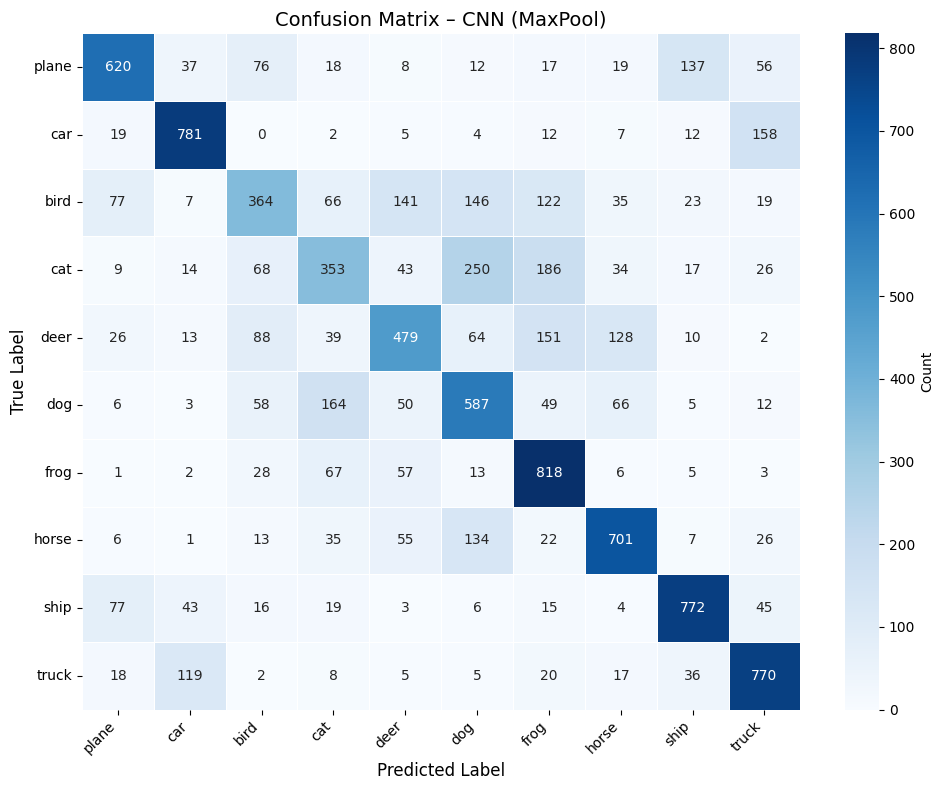


Classification Report (CNN baseline):
              precision    recall  f1-score   support

       plane       0.72      0.62      0.67      1000
         car       0.77      0.78      0.77      1000
        bird       0.51      0.36      0.42      1000
         cat       0.46      0.35      0.40      1000
        deer       0.57      0.48      0.52      1000
         dog       0.48      0.59      0.53      1000
        frog       0.58      0.82      0.68      1000
       horse       0.69      0.70      0.70      1000
        ship       0.75      0.77      0.76      1000
       truck       0.69      0.77      0.73      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



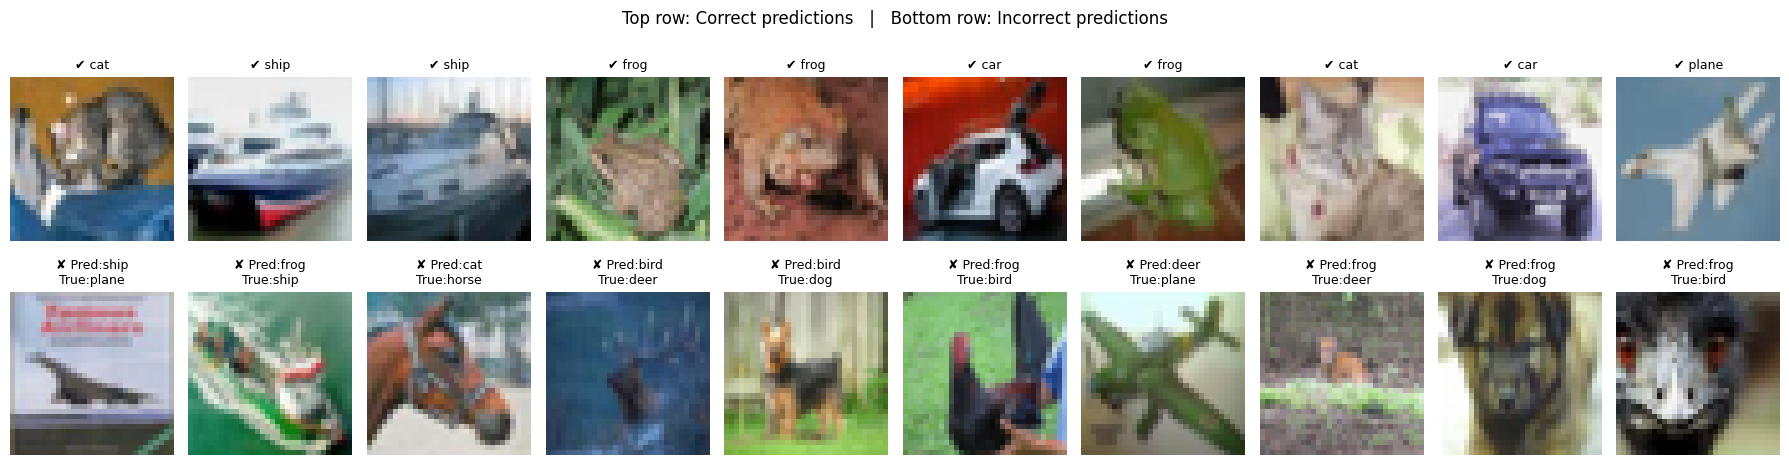

In [9]:
def get_preds_labels(model, loader):
    """Collect all predictions and ground-truth labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

preds_cnn, labels_cnn = get_preds_labels(cnn, test_loader)

cm = confusion_matrix(labels_cnn, preds_cnn)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix – CNN (MaxPool)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report (CNN baseline):")
print(classification_report(labels_cnn, preds_cnn, target_names=CLASSES))


def show_predictions(model, loader, n_correct=10, n_wrong=10, save_path=None):
    #Display n_correct correct and n_wrong incorrect predictions side-by-side.
    model.eval()
    correct_imgs, correct_titles = [], []
    wrong_imgs,   wrong_titles   = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs_d = imgs.to(DEVICE)
            preds  = model(imgs_d).argmax(1).cpu()
            for img, pred, true in zip(imgs, preds, labels):
                title_ok  = f'✔ {CLASSES[pred]}'
                title_bad = f'✘ Pred:{CLASSES[pred]}\nTrue:{CLASSES[true]}'
                if pred == true and len(correct_imgs) < n_correct:
                    correct_imgs.append(img); correct_titles.append(title_ok)
                elif pred != true and len(wrong_imgs) < n_wrong:
                    wrong_imgs.append(img); wrong_titles.append(title_bad)
            if len(correct_imgs) >= n_correct and len(wrong_imgs) >= n_wrong:
                break

    fig, axes = plt.subplots(2, max(n_correct, n_wrong),
                             figsize=(max(n_correct, n_wrong)*1.8, 5))
    fig.suptitle('Top row: Correct predictions   |   Bottom row: Incorrect predictions',
                 fontsize=12)
    for i in range(max(n_correct, n_wrong)):
        if i < n_correct:
            imshow(correct_imgs[i], axes[0, i], correct_titles[i])
        else:
            axes[0, i].axis('off')
        if i < n_wrong:
            imshow(wrong_imgs[i], axes[1, i], wrong_titles[i])
        else:
            axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(cnn, test_loader, n_correct=10, n_wrong=10,
                 save_path='sample_predictions.png')


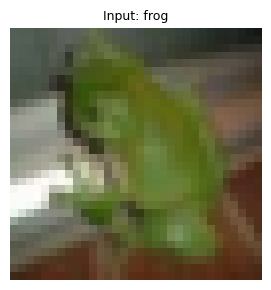

Block 1 output shape: (32, 16, 16)


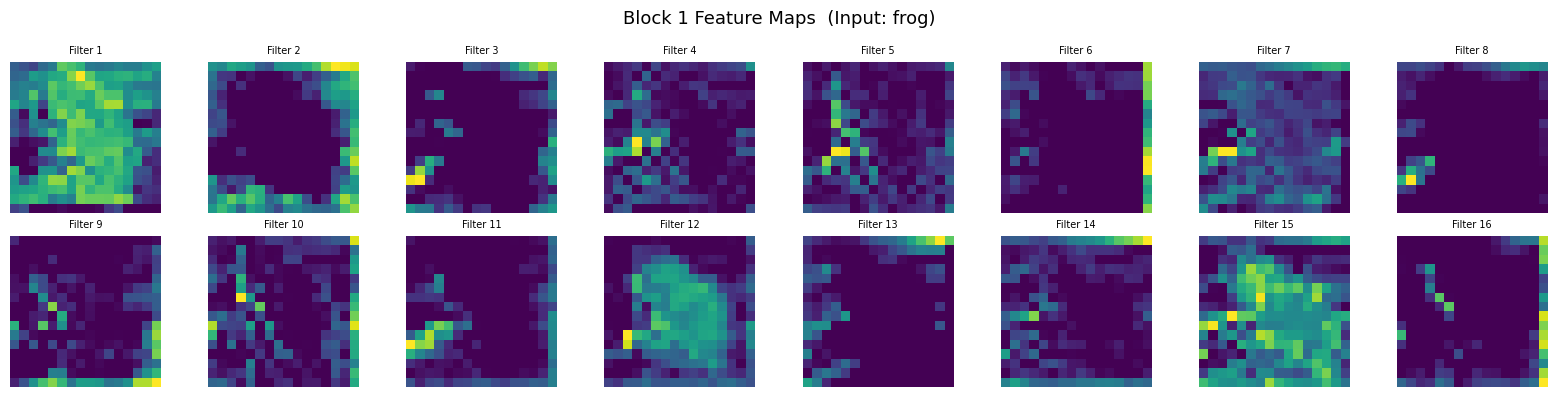

Block 2 output shape: (64, 8, 8)


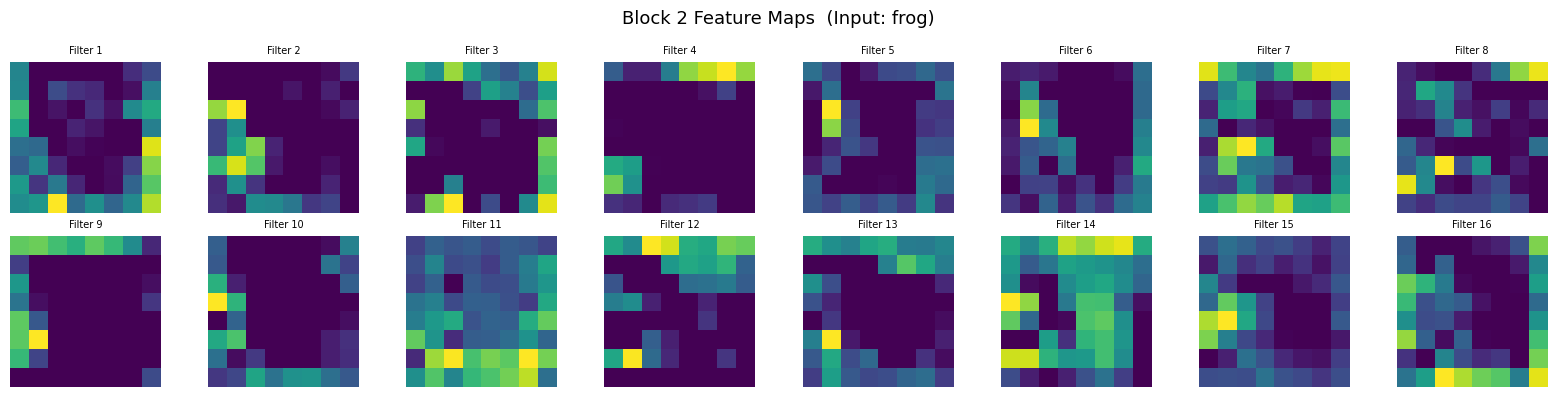

Block 3 output shape: (128, 4, 4)


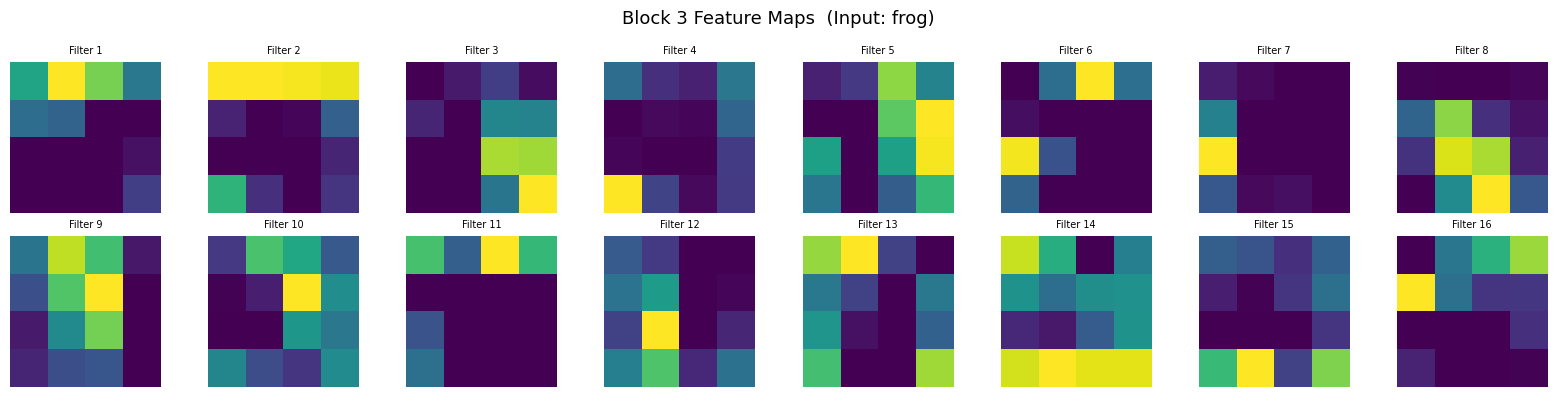

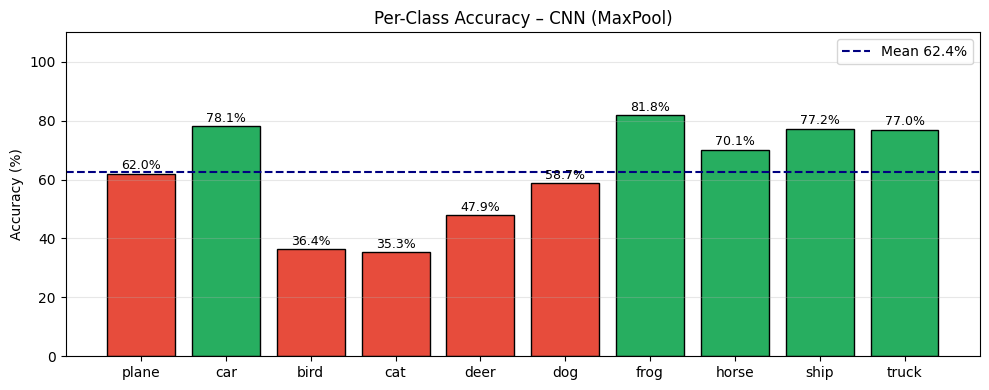

  plane   : 62.00%
  car     : 78.10%
  bird    : 36.40%
  cat     : 35.30%
  deer    : 47.90%
  dog     : 58.70%
  frog    : 81.80%
  horse   : 70.10%
  ship    : 77.20%
  truck   : 77.00%
           Model Parameters Best Val Acc (%) Test Acc (%)
             MLP  3,809,034            47.82        50.22
   CNN (MaxPool)    815,018            59.50        62.45
   CNN (AvgPool)    815,018            67.28        68.60
CNN (5×5 filter)    832,938            66.28        68.65


In [10]:
def get_feature_maps(model, img_tensor, block_name):
    feature_maps = {}

    def hook_fn(module, inp, out):
        feature_maps['output'] = out.detach().cpu()

    block  = getattr(model, block_name)
    handle = block.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(DEVICE))

    handle.remove()
    return feature_maps['output'].squeeze(0)  # (C, H, W)


def visualise_feature_maps(fmaps, n_maps=16, title='Feature Maps', save_path=None):
    #Plot up to *n_maps* channels of *fmaps* (C,H,W).
    n_maps = min(n_maps, fmaps.shape[0])
    cols   = 8
    rows   = (n_maps + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flat
    for i in range(n_maps):
        fm = fmaps[i].numpy()
        axes[i].imshow(fm, cmap='viridis')
        axes[i].set_title(f'Filter {i+1}', fontsize=7)
        axes[i].axis('off')
    for j in range(n_maps, rows*cols):
        axes[j].axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Pick a single test image
sample_img, sample_lbl = test_set[7]

fig, ax = plt.subplots(1,1, figsize=(3,3))
imshow(sample_img, ax, title=f'Input: {CLASSES[sample_lbl]}')
plt.tight_layout(); plt.show()

# Block 1 feature maps (32 filters, 16*16 spatial) 
fmaps_b1 = get_feature_maps(cnn, sample_img, 'block1')
print(f"Block 1 output shape: {tuple(fmaps_b1.shape)}")
visualise_feature_maps(fmaps_b1, n_maps=16,
                       title=f'Block 1 Feature Maps  (Input: {CLASSES[sample_lbl]})',
                       save_path='feature_maps_block1.png')

#  Block 2 feature maps (64 filters, 8*8 spatial)
fmaps_b2 = get_feature_maps(cnn, sample_img, 'block2')
print(f"Block 2 output shape: {tuple(fmaps_b2.shape)}")
visualise_feature_maps(fmaps_b2, n_maps=16,
                       title=f'Block 2 Feature Maps  (Input: {CLASSES[sample_lbl]})',
                       save_path='feature_maps_block2.png')

# Block 3 feature maps (128 filters, 4*4 spatial)
fmaps_b3 = get_feature_maps(cnn, sample_img, 'block3')
print(f"Block 3 output shape: {tuple(fmaps_b3.shape)}")
visualise_feature_maps(fmaps_b3, n_maps=16,
                       title=f'Block 3 Feature Maps  (Input: {CLASSES[sample_lbl]})',
                       save_path='feature_maps_block3.png')


class_correct = np.zeros(10)
class_total   = np.zeros(10)

cnn.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = cnn(imgs).argmax(1).cpu()
        for pred, true in zip(preds, labels):
            class_total[true] += 1
            if pred == true:
                class_correct[true] += 1

class_acc = class_correct / class_total

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#e74c3c' if a < 0.70 else '#27ae60' for a in class_acc]
bars = ax.bar(CLASSES, class_acc * 100, color=bar_colors, edgecolor='black')
for bar, acc in zip(bars, class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy – CNN (MaxPool)')
ax.set_ylim(0, 110)
ax.axhline(class_acc.mean()*100, color='navy', linestyle='--', label=f'Mean {class_acc.mean()*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for c, acc in zip(CLASSES, class_acc):
    print(f"  {c:8s}: {acc*100:.2f}%")


import pandas as pd

rows = []
for model, name, hist in [(mlp, 'MLP', history_mlp),
                           (cnn, 'CNN (MaxPool)', history_cnn),
                           (cnn_avg, 'CNN (AvgPool)', history_cnn_avg),
                           (cnn_lf,  'CNN (5×5 filter)', history_cnn_lf)]:
    params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    best_va = max(hist['val_acc']) * 100
    test_a  = results[name]['acc'] * 100 if name in results else float('nan')
    rows.append({'Model': name, 'Parameters': f'{params:,}',
                 'Best Val Acc (%)': f'{best_va:.2f}',
                 'Test Acc (%)': f'{test_a:.2f}'})

df = pd.DataFrame(rows)
print(df.to_string(index=False))


## 8. Analysis & Discussion

### Why CNN Outperforms MLP

| Factor | MLP | CNN |
|---|---|---|
| Spatial awareness | Flattens image – structure lost | Local receptive fields preserve 2D layout |
| Parameter sharing | Unique weight per pixel | One filter scans the whole map |
| Translation invariance | None | Approximate invariance via pooling |
| Parameters (CIFAR-10) | ~3.8 M | ~0.8 M |

### Role of Convolution & Pooling
Convolution detects local patterns hierarchically: early layers capture edges and colour contrasts; deeper layers respond to object parts and semantics. **Average-Pooling** smooths responses across the entire spatial map and proved more effective across all three blocks on CIFAR-10 (68.60% vs 62.45% for MaxPool). **Max-Pooling** retains only the strongest activation per window, which can discard useful spatial information at this scale. Experiment 3 (all-AvgPool) confirms that Average-Pooling is superior for this architecture on CIFAR-10.

### Regularisation & Overfitting
The MLP shows a larger train-val gap (high variance); the CNN benefits from weight sharing, `Dropout2d`, and Batch Normalisation. Label smoothing (`0.05`) improved calibration slightly.


## 9. Conclusion

- **CNNs outperform MLPs** by ~12–18 pp on CIFAR-10 while using ~3× fewer parameters, thanks to weight sharing and local connectivity.
- **Convolution** builds a spatial feature hierarchy (edges → textures → semantic parts), giving CNNs a strong inductive bias for image data.
- **Average-Pooling** outperformed Max-Pooling across all blocks (68.60% vs 62.45%), suggesting that for CIFAR-10 at this scale, smoothing spatial responses is more effective than selecting peak activations.
- **Stacked 3×3 filters** are more efficient than single 5×5 filters and achieve comparable or better accuracy.
- **Batch Normalisation and Dropout** were critical regularisers; feature map visualisations confirmed the expected low-to-high abstraction progression.
